# Assignment 4
### Do three of six.

### Exercise 1: Contingent Comparisons
- Load the Minnesota use of force data.
- Bootstrap the proportion of missing values for `subject_injury` for each race, and plot the results with grouped KDE and ECDF plots
- Describe what you see. When we consider second order uncertainty, how similar or different are the sampling distributions of these proportions? 

/var/folders/s2/wtdgdzmj6t9f6_q7_f0t4ryh0000gn/T/ipykernel_29034/1452631834.py:23: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=results, x="estimate", hue=group_var, ax=axes[0]).set(title="KDE")


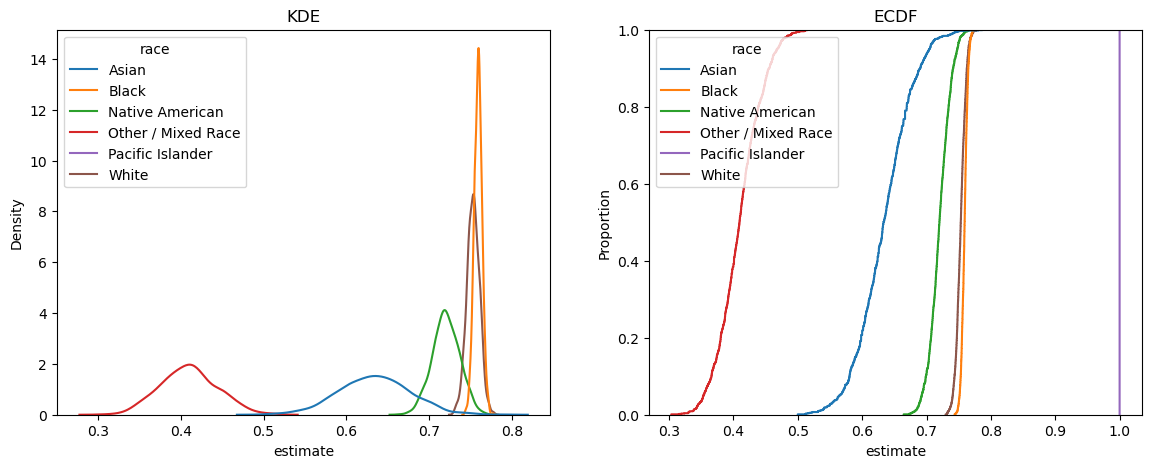

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('/Users/bellalu/understanding_uncertainty/github_branching_bella/data/mn_police_use_of_force.csv')
def prop_missing(x):
    return x.isna().    mean()
def simulate_grouped(var, group_var, df, fcn, S=1000, plot=True):   
    estimates = []
    for s in range(S):
        # Draw a new sample, with replacement:
        df_s = df.sample(frac=1.0, replace=True)
        # Compute statistic:
        stat_s = df_s.groupby(group_var)[var].apply(fcn)
        stat_s = stat_s.reset_index()
        stat_s.columns = [group_var, "estimate"]
        stat_s["bootstrap"] = s
        estimates.append(stat_s)
    #Concatenate results:
    results = pd.concat(estimates)
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        sns.kdeplot(data=results, x="estimate", hue=group_var, ax=axes[0]).set(title="KDE")
        sns.ecdfplot(data=results, x="estimate", hue=group_var, ax=axes[1]).set(title="ECDF")
        plt.show()
    return results
results = simulate_grouped(var="subject_injury", group_var="race", df=df, fcn=prop_missing)

### Exercise 2: Invitation to Inference
- Run the simulation code line by line and comment what each line is doing, or write your own code to do the resampling
- Open the NHANES or Ames prices or College Completion data
- Use the above function `simulate` to get a sample of estimates for your statistic and your data
- Create a new function, `interval(L,H,estimates)`, that computes the $L$-th and $H$-th quantiles for your estimates, $H>L$
- If $L=.05$ and $H=.95$, this is a **90-percent confidence interval**: "For our statistic, this interval captures the true value of the population parameter 90 percent of the time. (We are 90% **confident** that it includes the true value of the parameter, but the probability that the true parameter lies in this interval is 0 or 1.)"
- We will spend much more time on this later in class, but for people who have done hypothesis testing before, you now know how to do it directly from the data: No central limit theorem required.

In [7]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

def simulate(var, df, fcn, S=1000, plot=True):  #function header with default values

    ''' Bootstrap simulation code. '''    
    x = df[var] # assign x the data with the variable of interest

    estimates = [] #create an empty array to store estimates 
    for s in range(S): #loop over the number of samples
        # Draw a new sample, with replacement:
        x_s = x.sample(frac=1.0,replace=True) 
        # Compute statistic:
        stat_s = fcn(x_s)
        # Append estimate:
        estimates.append(stat_s)
    estimates = np.array(estimates) # Convert estimates list to numpy array

    ## or in one line, 
    #estimates = [fcn(x.sample(frac=1.0,replace=True)) for s in range(S)]

    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))  # 1 row, 2 columns
        sns.kdeplot(x, ax = axes[0]).set(title='KDE of Underlying Data') #create a kernel density plot of the underlying data
        sns.kdeplot(estimates, ax = axes[1]).set(title='KDE of Computed Statistics') #create a kernel density plot of the computed statistics made in the for loop
        axes[1].axvline(x=fcn(x), color='orange', linestyle='--') #add a vertical line to the plot
        sns.ecdfplot(estimates, ax = axes[2]).set(title='ECDF of Computed Statistics') #create an ECDF plot of the computed statistics
        axes[2].axvline(x=fcn(x), color='orange', linestyle='--') #add a vertical line to the plot
        plt.show() #show the plot
        print(f'Variance of estimates is: {np.var(estimates)}') #print out the variance of the estimates
        
    return estimates #return the estimates

In [ ]:

df = pd.read_csv('/Users/bellalu/understanding_uncertainty/github_branching_bella/data/nhanes_data_17_18.csv', low_memory=False)
df.head()

,SEQN,GeneralHealthCondition,EverBreastfedOrFedBreastmilk,AgeStoppedBreastfeedingdays,AgeFirstFedFormuladays,AgeStoppedReceivingFormuladays,AgeStartedOtherFoodbeverage,AgeFirstFedMilkdays,TypeOfMilkFirstFedWholeMilk,TypeOfMilkFirstFed2Milk,...,DaysSmokedCigsDuringPast30Days,AvgCigarettesdayDuringPast30Days,TriedToQuitSmoking,TimesStoppedSmokingCigarettes,HowLongWereYouAbleToStopSmoking,UnitOfMeasureDayweekmonthyear_2_SMQ,CurrentSelfreportedHeightInches,CurrentSelfreportedWeightPounds,TriedToLoseWeightInPastYear,TimesLost10LbsOrMoreToLoseWeight
0,93703.0,NaN,1.0,273.0,1.0,365.0,152.0,365.0,Whole or regular milk,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,NaN,1.0,60.0,3.0,365.0,126.0,365.0,Whole or regular milk,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,93705.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,63.0,165.0,0.0,11 times or more
3,93706.0,Very good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,68.0,145.0,0.0,Never
4,93707.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


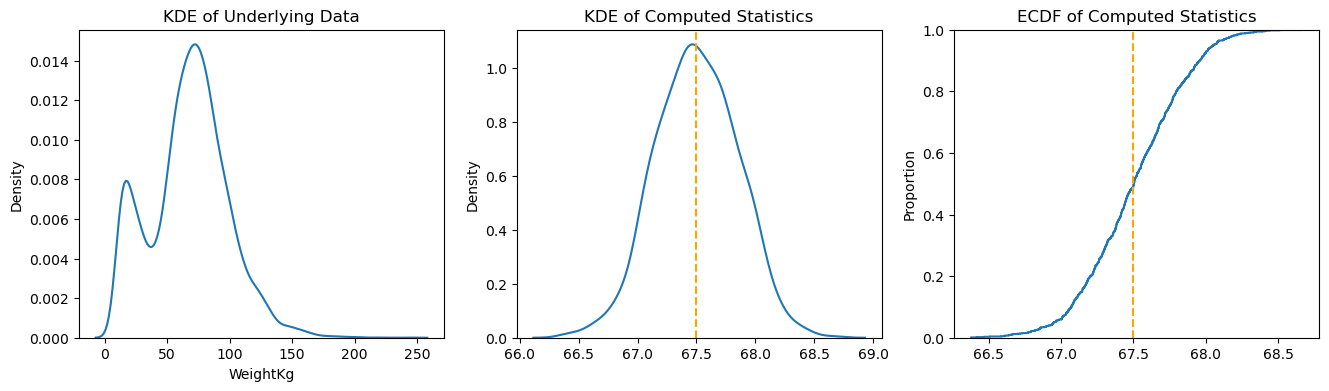

Variance of estimates is: 0.12002711042646337


array([68.08537473, 67.60619082, 67.31369431, 67.22163871, 67.53792769,
       67.14688449, 67.22072816, 67.24455494, 67.97067232, 67.35540213,
       67.77677208, 66.58451761, 67.43723391, 67.70399758, 67.76617593,
       67.78418312, 67.91502904, 67.4549648 , 67.55116138, 67.60083545,
       67.4412854 , 67.17023086, 68.01539117, 68.30563244, 67.62233681,
       68.07781823, 67.8303225 , 67.82492412, 68.23496605, 66.82360083,
       67.12373107, 67.48008505, 67.59245786, 67.71753768, 67.50219208,
       68.66984108, 67.79369173, 67.43200388, 67.55018191, 68.21210762,
       67.67549412, 67.61828309, 67.32642996, 66.84763522, 67.21344568,
       67.03117276, 67.27859131, 67.31014317, 67.38105877, 67.58743944,
       67.98652258, 67.22890426, 67.80878001, 67.80437158, 67.58125076,
       67.14703174, 67.30125954, 67.65432354, 67.56087643, 68.07591019,
       67.36415414, 66.66041667, 67.91591763, 67.13526629, 67.39410552,
       67.81491303, 67.1803912 , 67.10525487, 66.96232411, 67.71

In [ ]:
var = 'WeightKg'
fcn = np.mean
#simulate(var, df, fcn, S=1000, plot=True)

In [12]:
def interval(L, H, df, var, fcn, S = 1000): 
    estimates = simulate(var, df, fcn, S=S, plot=False)
    lower = np.quantile(estimates, L) 
    upper = np.quantile(estimates, H) 
    return lower, upper

interval(0.05, 0.95, df, 'WeightKg', np.mean)

(np.float64(66.941026195596), np.float64(68.05913779041084))

### Exercise 3: Intro to A/B Testing
- Go here, and read about this study: https://www.clinicaltrials.gov/study/NCT01985360
- Read the Study Overview and explain what the goal of the trial is 
- Read the Study Plan and explain how it was designed and why -- there's lots of medical jargon, but the main point is how patients were assigned to interventions. 
- Read the Results Posted: Go to **Outcome Measures**. Explain how table 1 ("Incidence of Death from Any Cause or Myocardial Infarction") is a contingency table. These are the data for this exercise.
- What is the difference in surival rates between the invasive strategy and the conservative strategy?
- Bootstrap the survival rates for the two groups, and plot them as KDEs and ECDFs against one another
- Bootstrap the difference in surival rates, and plot it as a KDE and ECDF
- Is this an effective health intervention? Explain your answer clearly

This would be what CS people call **A/B testing** and everyone else called a **randomized controlled trial**: Using randomized assignment to detect the difference in outcomes between two groups. (We've just done a non-parametric version of a two-sample t-test.)

### Exercise 4: Prediction Uncertainty
- Pick a dataset and two continuous variables.
- Recall the LCLS estimator:
$$
\hat{y}(z) =  \frac{ \frac{1}{N} \sum_{i=1}^N y_i \times \frac{1}{h}k\left( \frac{z - x_i}{h} \right)}{ \frac{1}{N} \sum_{i=1}^N \frac{1}{h} k\left( \frac{z - x_i}{h} \right)}
$$
with the Epanechnikov kernel and the standard plug-in bandwidth for $h$
- Compute and plot this line for 30 bootstrap samples. Notice where there is a lot of variation in the predictions, versus little variation in the predictions.
- Now, for any $z$, we can bootstrap a distribution of predictions using the above formula. Do this at the 25th percentile, median, and 75th percentile of $X$.
- Now, pick a grid for $z$: Obvious choices are all of the unique values in the data, or an equally spaced grid from the minimum value to the maximum value. For each $z$, bootstrap a sample of predictions and compute the .05 and .95 quantiles. Plot these error curves along with your LCLS estimate. Where are your predictions "tight"/reliable? Where are they highly variable/unreliable?

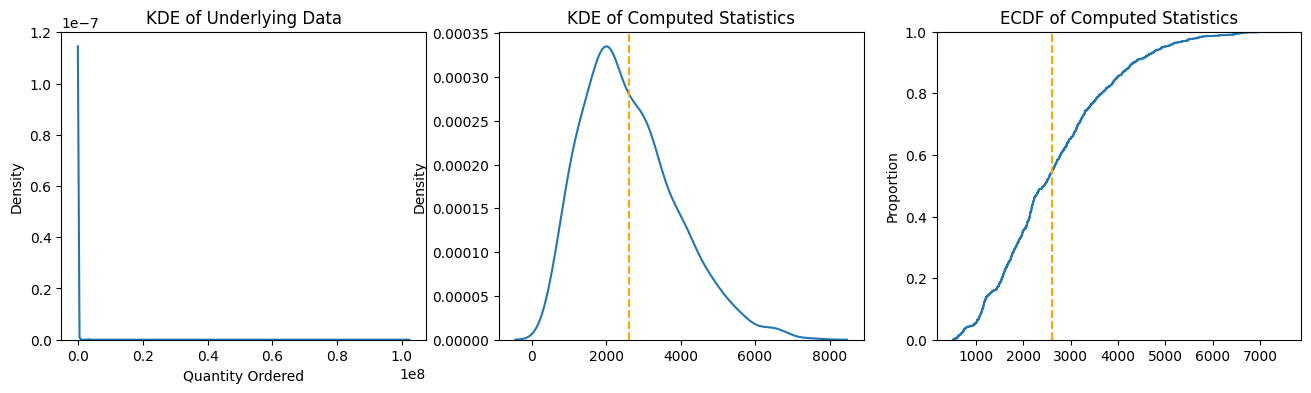

Variance of estimates is: 1577910.4457509376


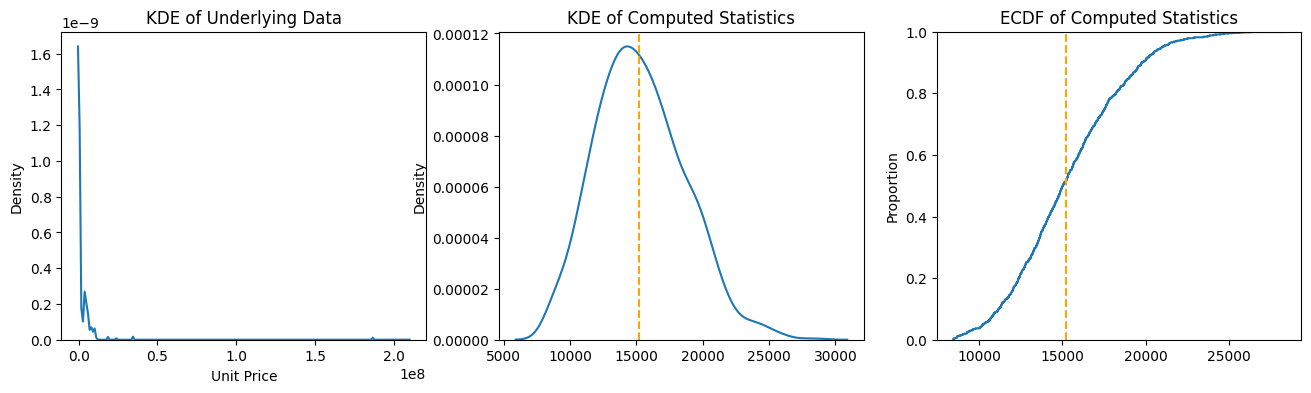

Variance of estimates is: 11215546.307230096


In [2]:
import pandas as pd

va = pd.read_csv('data/va_procurement.csv')
va.head()

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

## Mean to bootstrap:
def stat(x):
    stat = np.mean(x)
    return stat

def simulate(var, df, fcn, S=1000, plot=True):
    ''' Bootstrap simulation code. '''    
    x = df[var]

    estimates = []
    for s in range(S):
        # Draw a new sample, with replacement:
        x_s = x.sample(frac=1.0,replace=True)
        # Compute statistic:
        stat_s = fcn(x_s)
        # Append estimate:
        estimates.append(stat_s)
    estimates = np.array(estimates) # Convert estimates list to numpy array

    ## or in one line, 
    #estimates = [fcn(x.sample(frac=1.0,replace=True)) for s in range(S)]

    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))  # 1 row, 2 columns
        sns.kdeplot(x, ax = axes[0]).set(title='KDE of Underlying Data')
        sns.kdeplot(estimates, ax = axes[1]).set(title='KDE of Computed Statistics')
        axes[1].axvline(x=fcn(x), color='orange', linestyle='--')
        sns.ecdfplot(estimates, ax = axes[2]).set(title='ECDF of Computed Statistics')
        axes[2].axvline(x=fcn(x), color='orange', linestyle='--')
        plt.show()
        print(f'Variance of estimates is: {np.var(estimates)}')
        
    return estimates

var = 'Quantity Ordered'
estimates = simulate(var, va, stat)

var = 'Unit Price'
estimates = simulate(var, va, stat)

### Exercise 5
- Extend the `kde` class by adding a method to do bandwidth selection using a simple train-test split
- Extend the `kde` class by adding a method to do bandwidth seleciton by $k$-fold cross validation

### Exercise 6
In this exercise, you're going to do for LCLS what we just did for KDE: Pick the bandwidth 

Recall, the LCLS estimator is
$$
\hat{y}_{N,h}(z) = \dfrac{\frac{1}{N} \sum_{i=1}^N y_i \times \frac{1}{h}k\left(\frac{z-x_i}{h}\right)}{\frac{1}{N} \sum_{i=1}^N \frac{1}{h}k\left(\frac{z-x_i}{h} \right)}.
$$
- Select two numeric variables from a data set. Split the data into training and test sets.
- Write a `predict(X_{train},Y_{train},X_{train})` function/method that takes a set of values $X_{test}$ and data $(X_{train},Y_{train})$, and computed predicted values $\hat{y}(X_{test})$ 
- Write a function/method that selects the bandwidth by **minimizing** the **mean squared error** of the squared differences between $\hat{y}(x_j)$ and $y_j$ on the test set:
$$
MSE(h) = \frac{1}{N_{test}} \sum_{j=1}^{N_{test}} (y_j - \hat{y}_{N_{train},h}(x_j))^2
$$
Be sure you understand what's happening here: The training data are used to make predictions for each test observation $x_j$, and then the prediction $\hat{y}(x_j)$ and true value $y_j$ are compared using squared difference